/home/gabriel/Documents/ic/rgpe/.venv/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gabriel/Documents/ic/rgpe/.venv/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/gabriel/Documents/ic/rgpe/.venv/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gabriel/Documents/ic/rgpe/.venv/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/gabriel/Documents/ic/rgpe/.venv/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gabriel/Documents/ic/rgpe/.venv/lib64/python3.13/site-packages/numpy/lib/_funct

(257,)


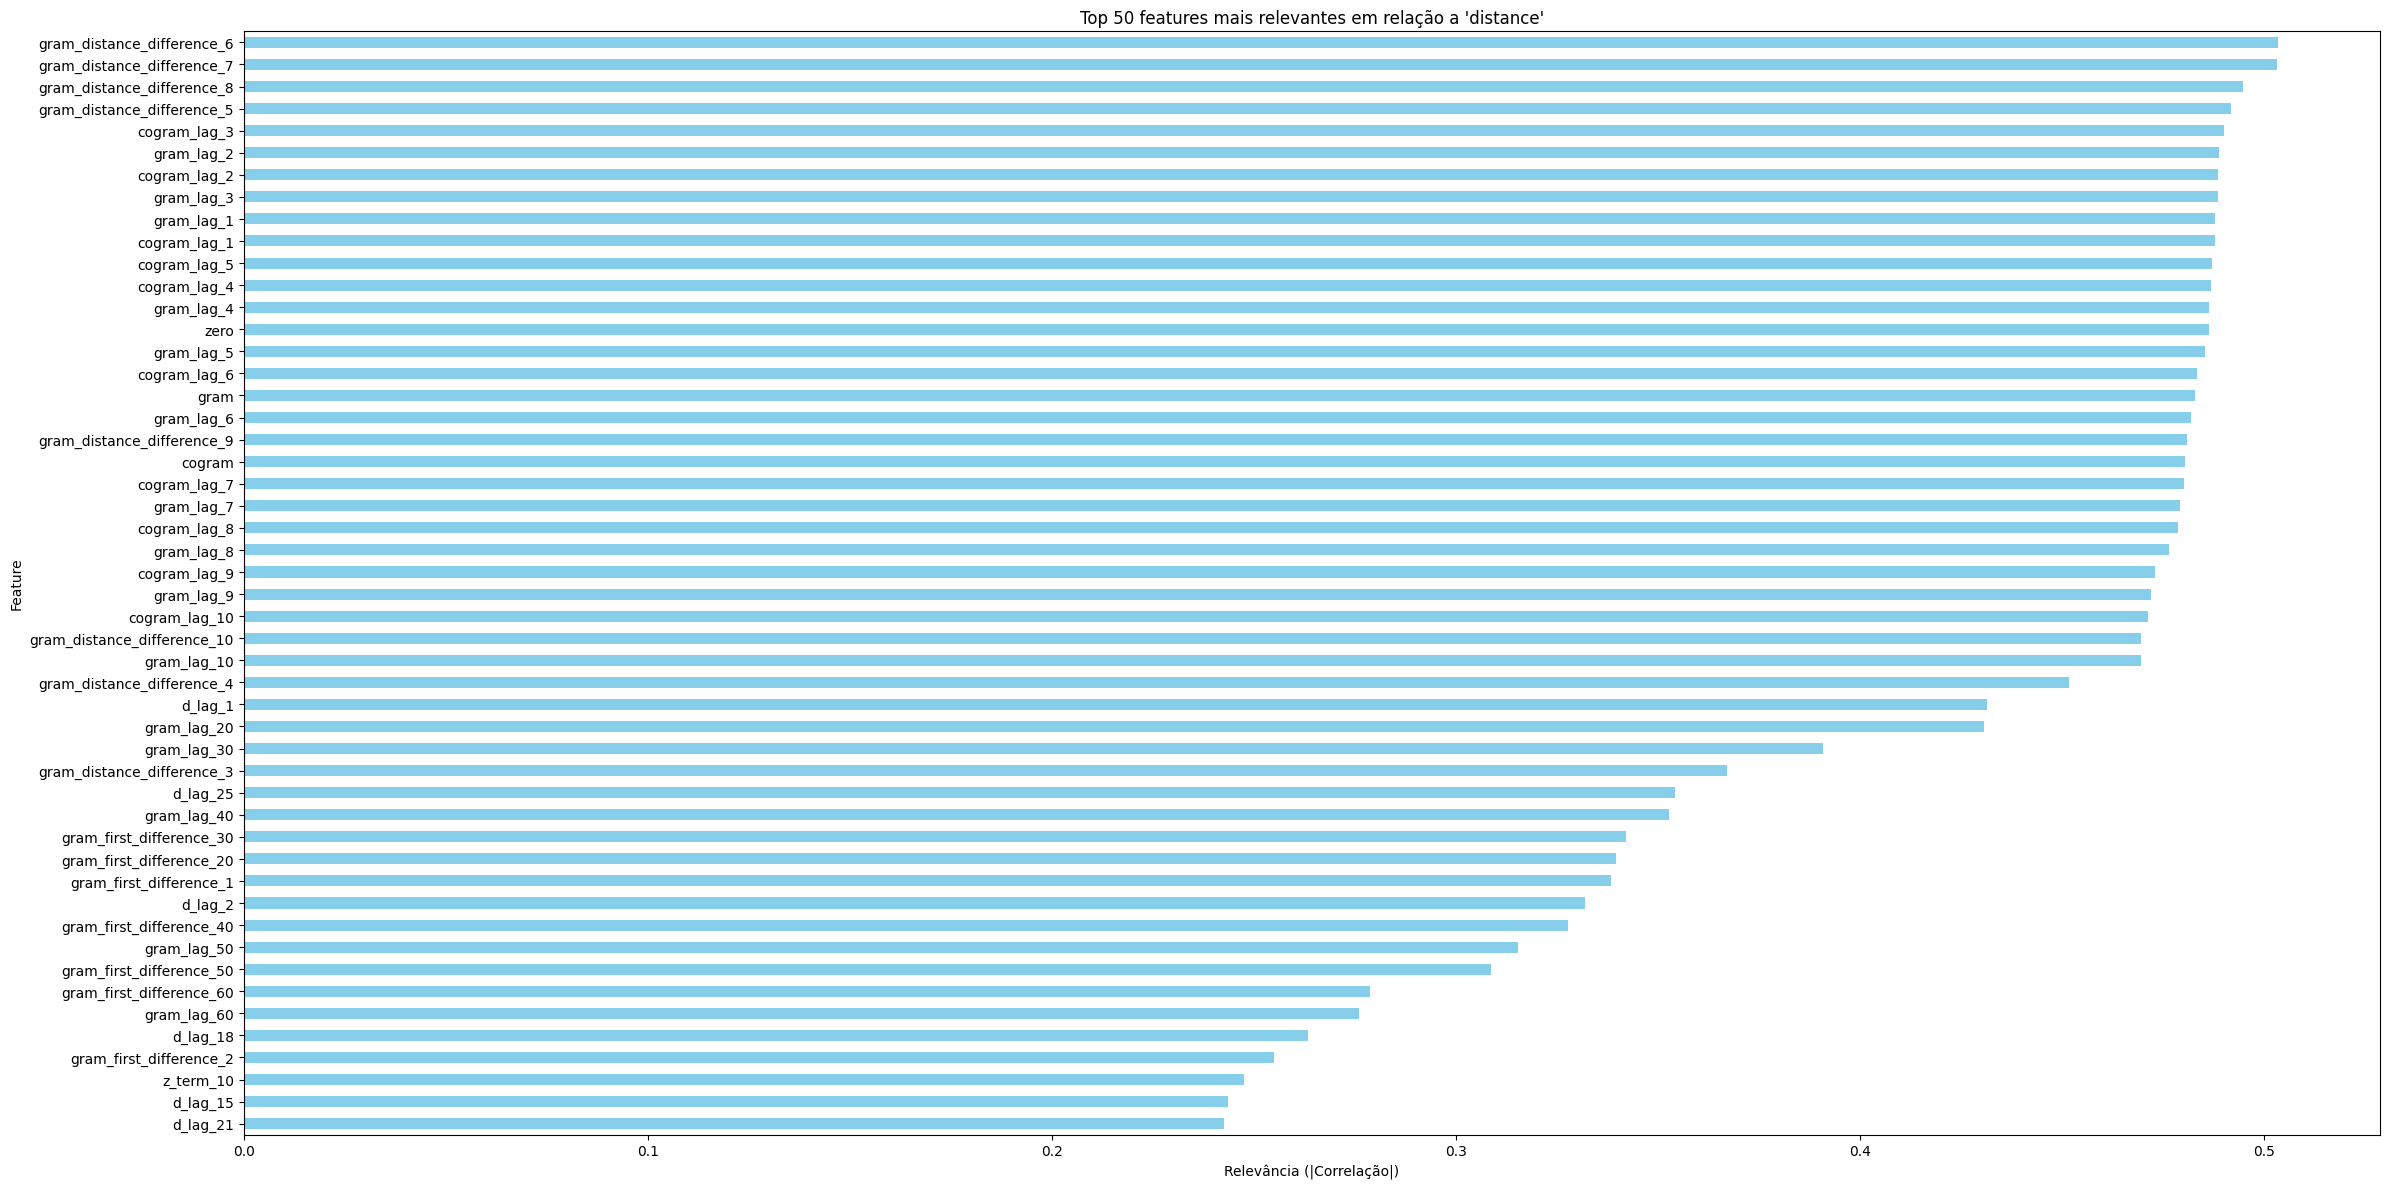

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

X = pd.read_csv("../dataset/custom.csv").fillna(0)
y = pd.read_csv("../dataset/distances.csv")["distance"]


correlations = X.corrwith(y).abs()


top_features = correlations.sort_values(ascending=False).head(50)

print(correlations.shape)


plt.figure(figsize=(24, 12))
top_features.sort_values().plot(kind="barh", color="skyblue")
plt.xlabel("Relevância (|Correlação|)")
plt.ylabel("Feature")
plt.title(f"Top 50 features mais relevantes em relação a 'distance'")
plt.tight_layout()
plt.show()

# Usando correlação de Pearson para filtrar as variáveis

In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("../dataset/custom.csv")

def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr(method='pearson').abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"Removendo {len(to_drop)} features altamente correlacionadas")

    return df.drop(columns=to_drop)


df_filtered = remove_highly_correlated_features(df, threshold=0.97)
print(f"Dataset original: {df.shape} features")
print(f"Dataset filtrado: {df_filtered.shape} features")
print(df_filtered.head())
df_filtered.to_csv("../dataset/custom_filtered.csv", index=False)


Removendo 125 features altamente correlacionadas
Dataset original: (100000, 406) features
Dataset filtrado: (100000, 281) features
        gram    z_gram  z_term_2  z_term_3  z_term_4  z_term_5  z_term_6  \
0   9.666908 -1.531821 -1.292795  0.423354 -0.671319  0.884427 -0.034295   
1  17.845600  2.340182  1.386931  0.840271  0.923578 -0.806528  0.692173   
2  23.170283 -1.457427  1.327280 -1.095202 -0.761673 -0.821016  0.637511   
3  27.670182  2.845091  1.337928  0.607158  0.790050  0.761986  0.631187   
4  31.717980 -0.925265  1.414189  1.107063 -0.999930 -0.634199 -0.784172   

   z_term_7  z_term_8  z_term_9  ...  z_gram_sin_6  z_gram_sqrt_6  \
0 -0.755365 -0.221480  0.487438  ...           NaN            NaN   
1 -0.745234  0.587473  0.039389  ...           NaN            NaN   
2 -0.339520  0.347313 -0.532800  ...           NaN            NaN   
3 -0.685014  0.388066 -0.298026  ...           NaN            NaN   
4 -0.335107  0.706995 -0.558922  ...           NaN            NaN  

# Usando algoritmo genético para pegar as mais importantes

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn_genetic import GAFeatureSelectionCV



X = pd.read_csv("../dataset/custom_filtered.csv").fillna(0)
y = pd.read_csv("../dataset/distances.csv")["distance"]

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


estimator = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

evolved_estimator = GAFeatureSelectionCV(
    estimator=estimator,
    cv=3,
    scoring="r2",
    population_size=100,
    generations=25,
    n_jobs=-1,
    verbose=True,
    crossover_probability=0.5,
    mutation_probability=0.2,
    elitism=True
)

evolved_estimator.fit(X_train, y_train)

mask = evolved_estimator.support_
selected_features = X.columns[mask]

print("Features selecionadas pelo GA:")
print(selected_features.tolist())

score = evolved_estimator.score(X_test, y_test)
print(f"R² no conjunto de teste: {score:.4f}")


Shape de X: (100000, 281)
Shape de y: (100000,)


/usr/local/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


KeyboardInterrupt: 